# Eticas AI Risk Taxonomy: Crosswalk Analysis

## Overview

This notebook computes alignment between Eticas AI Risk Taxonomy and AI Atlas Nexus's existing risk taxonomies:
- IBM Risk Atlas
- MIT AI Risk Repository
- NIST GenAI Profile
- AIR 2024 / AI Risk Taxonomy
- OWASP LLM Top 10 2.0

The analysis identifies:
1. **Agreements**: Where taxonomies align with exact/close matches
2. **Eticas Granularity**: Novel categories like "Agentic AI" and "Environmental Impact"
3. **Divergences**: Where terms or conceptualizations differ
4. **Hierarchical Structure**: How Eticas organizes risks into risk groups

## Dependencies

Ensure you have followed installation instructions:

```bash
git clone git@github.com:IBM/ai-atlas-nexus.git
cd ai-atlas-nexus
python3.12 -m venv v-ai-atlas-nexus
source v-ai-atlas-nexus/bin/activate
python3.12 -m pip install -e .
```

In [1]:
# Core imports
from rich import print
from rich.console import Console
from rich.table import Table
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from pydantic import BaseModel
import matplotlib.pyplot as plt
import seaborn as sns

from ai_atlas_nexus.ai_risk_ontology.datamodel.ai_risk_ontology import Risk, RiskGroup
from ai_atlas_nexus import AIAtlasNexus

# Display settings
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
console = Console()

/Users/ingevejs/Documents/workspace/ingelise/risk-atlas-nexus-worktrees/iv_eticas_notebook/v-ai-atlas-nexus/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initialize AI Atlas Nexus

In [2]:
# Initialize the knowledge graph
ran = AIAtlasNexus()

# Get Eticas taxonomy components
eticas_risks = ran.get_all_risks(taxonomy='eticas-ai-risk-taxonomy')
all_groups = ran.get_all('groups')
eticas_groups = [g for g in all_groups if hasattr(g, 'isDefinedByTaxonomy') and g.isDefinedByTaxonomy == 'eticas-ai-risk-taxonomy']

print(f"\n# Total risks available: {len(ran.get_all_risks())}")
print(f"# Available taxonomies: {len(ran.get_all_taxonomies())}")
print(f"\n# Eticas Risks: {len(eticas_risks)}")
print(f"# Eticas Risk Groups: {len(eticas_groups)}")
print(f"# Total Eticas entities: {len(eticas_risks) + len(eticas_groups)}")

[2026-08-14 14:36:21:253] - INFO - AIAtlasNexus - Created AIAtlasNexus instance. Base_dir: None


# Total risks available: 620

# Available taxonomies: 17

# Eticas Risks: 64

# Eticas Risk Groups: 27

# Total Eticas entities: 91

## Eticas Taxonomy Overview

In [3]:
# Get Eticas taxonomy
eticas_taxonomy = ran.get_by_id('taxonomy', 'eticas-ai-risk-taxonomy')

print(f"\nEticas AI Risk Taxonomy v{eticas_taxonomy.version}")
print(f"\nDescription: {eticas_taxonomy.description}")

# Count top-level categories (groups with no parent)
top_level_groups = [g for g in eticas_groups if not hasattr(g, 'broader') or not g.broader or len(g.broader) == 0]
print(f"\n=== Top-level Risk Categories ===")
print(f"Count: {len(top_level_groups)}\n")
for cat in sorted(top_level_groups, key=lambda x: x.name):
    # Count children (risks and subgroups)
    child_risks = [r for r in eticas_risks if r.isPartOf and cat.id in r.isPartOf]
    child_groups = [g for g in eticas_groups if hasattr(g, 'broader') and g.broader and cat.id in g.broader]
    total_children = len(child_risks) + len(child_groups)
    print(f"  {cat.name}: {total_children} entities ({len(child_groups)} subgroups, {len(child_risks)} risks)")

Eticas AI Risk Taxonomy v2.0.0

Description: An auditor-facing AI risk taxonomy developed by Eticas, an AI auditing company. Covers Bias & 
Fairness, Privacy & Confidentiality, Reliability, Security & Misuse, Transparency & Explainability, Governance, 
Environmental Impact, Autonomy & Agency, Organisational Readiness, and Agentic AI. Designed for operationalisation 
in third-party AI audits.

=== Top-level Risk Categories ===

Count: 8

Agentic AI: 2 entities (2 subgroups, 0 risks)

...

Governance: 19 entities (3 subgroups, 16 risks)

Privacy & Confidentiality: 3 entities (3 subgroups, 0 risks)

Reliability: 12 entities (3 subgroups, 9 risks)

Security & Misuse: 3 entities (3 subgroups, 0 risks)

Transparency & Explainability: 4 entities (2 subgroups, 2 risks)

## Helper Functions

In [4]:
class RiskSimplified(BaseModel):
    id: str
    name: str
    isPartOf: str | None
    isDefinedByTaxonomy: str | None


def get_match_summary(risk, target_taxonomies=None):
    """
    Summarize all SKOS matches for a risk, optionally filtered by target taxonomies.
    
    Args:
        risk: Risk object
        target_taxonomies: List of taxonomy IDs to filter by (None = all)
    
    Returns:
        dict: Match type -> list of (risk_id, taxonomy, name) tuples
    """
    matches = {
        'exactMatch': [],
        'closeMatch': [],
        'broadMatch': [],
        'narrowMatch': [],
        'relatedMatch': []
    }
    
    # Map SKOS match types to actual attribute names
    attr_map = {
        'exactMatch': 'exact_mappings',
        'closeMatch': 'close_mappings',
        'broadMatch': 'broad_mappings',
        'narrowMatch': 'narrow_mappings',
        'relatedMatch': 'related_mappings'
    }
    
    for match_type, attr_name in attr_map.items():
        match_list = getattr(risk, attr_name, [])
        if match_list:
            for match_id in match_list:
                matched_risk = ran.get_risk(id=match_id)
                if matched_risk:
                    taxonomy = matched_risk.isDefinedByTaxonomy
                    if target_taxonomies is None or taxonomy in target_taxonomies:
                        matches[match_type].append((
                            match_id,
                            taxonomy,
                            matched_risk.name
                        ))
    
    return matches


def count_matches_by_taxonomy(eticas_risks, target_taxonomies):
    """
    Count matches from Eticas to each target taxonomy by match type.
    
    Args:
        eticas_risks: List of Eticas Risk objects
        target_taxonomies: List of taxonomy IDs
    
    Returns:
        pd.DataFrame: Match counts by taxonomy and match type
    """
    results = []
    
    for tax in target_taxonomies:
        counts = {
            'taxonomy': tax,
            'exactMatch': 0,
            'closeMatch': 0,
            'broadMatch': 0,
            'narrowMatch': 0,
            'relatedMatch': 0,
            'total': 0
        }
        
        for risk in eticas_risks:
            matches = get_match_summary(risk, [tax])
            for match_type, match_list in matches.items():
                if match_list:
                    counts[match_type] += len(match_list)
                    counts['total'] += len(match_list)
        
        results.append(counts)
    
    return pd.DataFrame(results)


def identify_unmapped_eticas_risks(eticas_risks, target_taxonomies):
    """
    Find Eticas risks with no mappings to target taxonomies.
    
    Args:
        eticas_risks: List of Eticas Risk objects
        target_taxonomies: List of taxonomy IDs
    
    Returns:
        List of (risk_id, name, parent_category) tuples
    """
    unmapped = []
    
    for risk in eticas_risks:
        matches = get_match_summary(risk, target_taxonomies)
        total_matches = sum(len(v) for v in matches.values())
        
        if total_matches == 0:
            parent = None
            if risk.isPartOf:
                # Try to get parent group
                parent_id = risk.isPartOf[0]
                parent_group = next((g for g in eticas_groups if g.id == parent_id), None)
                if parent_group:
                    parent = parent_group.name
                else:
                    parent_risk = ran.get_risk(id=parent_id)
                    parent = parent_risk.name if parent_risk else parent_id
            
            unmapped.append((risk.id, risk.name, parent))
    
    return unmapped


def create_crosswalk_dataframe(eticas_risks, target_taxonomy):
    """
    Create detailed crosswalk dataframe for Eticas vs one target taxonomy.
    
    Args:
        eticas_risks: List of Eticas Risk objects
        target_taxonomy: Taxonomy ID
    
    Returns:
        pd.DataFrame with crosswalk details
    """
    rows = []
    
    for risk in eticas_risks:
        matches = get_match_summary(risk, [target_taxonomy])
        
        # Get parent category
        parent = None
        if risk.isPartOf:
            parent_id = risk.isPartOf[0]
            parent_group = next((g for g in eticas_groups if g.id == parent_id), None)
            if parent_group:
                parent = parent_group.name
            else:
                parent_risk = ran.get_risk(id=parent_id)
                parent = parent_risk.name if parent_risk else parent_id
        
        # Collect all matches
        all_matches = []
        match_types = []
        
        for match_type, match_list in matches.items():
            for match_id, _, match_name in match_list:
                all_matches.append(f"{match_name} ({match_id})")
                match_types.append(match_type)
        
        if all_matches:
            row = {
                'eticas_id': risk.id,
                'eticas_name': risk.name,
                'eticas_parent': parent,
                'match_type': ', '.join(match_types),
                'target_matches': ' | '.join(all_matches),
                'num_matches': len(all_matches)
            }
            rows.append(row)
    
    return pd.DataFrame(rows)

## Alignment Analysis: Match Count Summary

In [5]:
# Define target taxonomies
target_taxonomies = [
    'ibm-risk-atlas',
    'mit-ai-risk-repository',
    'nist-ai-rmf',
    'ai-risk-taxonomy',  # AIR 2024
    'owasp-llm-2.0'
]

# Count matches by taxonomy
match_counts = count_matches_by_taxonomy(eticas_risks, target_taxonomies)

print("\n=== Match Counts by Taxonomy ===")
print(match_counts.to_string(index=False))

# Summary statistics
print(f"\n=== Summary Statistics ===")
print(f"Total Eticas risks: {len(eticas_risks)}")
print(f"Total Eticas risk groups: {len(eticas_groups)}")
print(f"Total mappings created: {match_counts['total'].sum()}")
print(f"Average mappings per taxonomy: {match_counts['total'].mean():.1f}")
print(f"Risks with mappings: {len([r for r in eticas_risks if any(get_match_summary(r, target_taxonomies).values())])}")
print(f"Coverage: {len([r for r in eticas_risks if any(get_match_summary(r, target_taxonomies).values())]) / len(eticas_risks) * 100:.1f}%")

=== Match Counts by Taxonomy ===

taxonomy  exactMatch  closeMatch  broadMatch  narrowMatch  relatedMatch  total
        ibm-risk-atlas           9          16           0            0             0     25
mit-ai-risk-repository           1          22           0           10             3     36
           nist-ai-rmf           2           7           0            7             2     18
      ai-risk-taxonomy           0           0           0            0             0      0
         owasp-llm-2.0           0           0           0            0             0      0

=== Summary Statistics ===

Total Eticas risks: 64

Total Eticas risk groups: 27

Total mappings created: 79

Average mappings per taxonomy: 15.8

Risks with mappings: 43

Coverage: 67.2%

## Match Strength Distribution

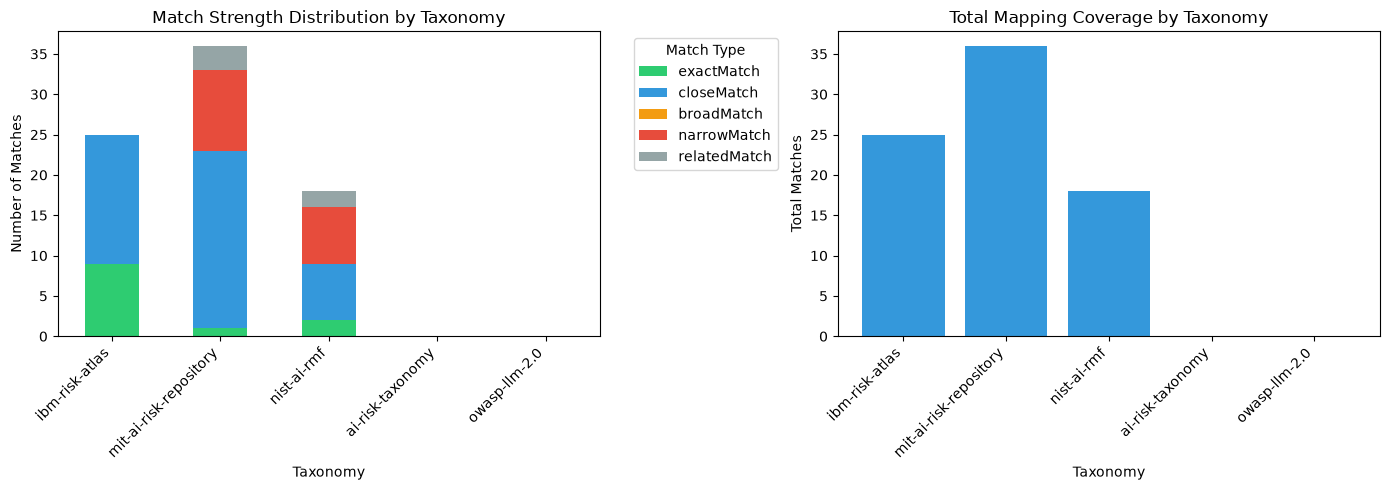

In [6]:
# Visualize match strength distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart by taxonomy
match_types = ['exactMatch', 'closeMatch', 'broadMatch', 'narrowMatch', 'relatedMatch']
match_counts[match_types].plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
)
axes[0].set_xticklabels(match_counts['taxonomy'], rotation=45, ha='right')
axes[0].set_xlabel('Taxonomy')
axes[0].set_ylabel('Number of Matches')
axes[0].set_title('Match Strength Distribution by Taxonomy')
axes[0].legend(title='Match Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Total matches by taxonomy
axes[1].bar(range(len(match_counts)), match_counts['total'], color='#3498db')
axes[1].set_xticks(range(len(match_counts)))
axes[1].set_xticklabels(match_counts['taxonomy'], rotation=45, ha='right')
axes[1].set_xlabel('Taxonomy')
axes[1].set_ylabel('Total Matches')
axes[1].set_title('Total Mapping Coverage by Taxonomy')

plt.tight_layout()
plt.show()

## Eticas Hierarchical Structure

Eticas organizes risks into a 2-3 level hierarchy:
- **Top-level categories**: Major risk domains (e.g., Bias & Fairness, Privacy, Security)
- **Sub-categories**: More specific risk groupings (e.g., Outcome Disparities, Representational Harm)
- **Risks**: Individual risk concepts (e.g., Disparate Impact, Stereotyping)

In [7]:
# Build hierarchy view
print("=== Eticas Taxonomy Hierarchy ===")
print(f"\nTotal: {len(top_level_groups)} top-level categories, {len(eticas_groups)} total groups, {len(eticas_risks)} risks\n")

for top_group in sorted(top_level_groups, key=lambda x: x.name):
    print(f"\n📁 {top_group.name} ({top_group.id})")
    
    # Get sub-groups
    sub_groups = [g for g in eticas_groups if hasattr(g, 'broader') and g.broader and top_group.id in g.broader]
    
    # Get direct risks (no sub-group parent)
    direct_risks = [r for r in eticas_risks if r.isPartOf and top_group.id in r.isPartOf]
    
    if sub_groups:
        for sub_group in sorted(sub_groups, key=lambda x: x.name):
            sub_risks = [r for r in eticas_risks if r.isPartOf and sub_group.id in r.isPartOf]
            print(f"  📂 {sub_group.name} ({len(sub_risks)} risks)")
            for risk in sorted(sub_risks[:3], key=lambda x: x.name):  # Show first 3
                print(f"     • {risk.name}")
            if len(sub_risks) > 3:
                print(f"     ... and {len(sub_risks) - 3} more")
    
    if direct_risks:
        print(f"  Direct risks: {len(direct_risks)}")
        for risk in sorted(direct_risks[:3], key=lambda x: x.name):
            print(f"     • {risk.name}")
        if len(direct_risks) > 3:
            print(f"     ... and {len(direct_risks) - 3} more")

=== Eticas Taxonomy Hierarchy ===

Total: 8 top-level categories, 27 total groups, 64 risks

📁 Agentic AI (eticas-agentic-ai)

📂 Autonomous Actions and Tool Use (5 risks)

• Excessive agency

...

• AI system explainability

• Right to explanation and contestation

Direct risks: 2

• AI system explainability

• Right to explanation and contestation

## Eticas-Specific Granularity: Unmapped Risks

These are Eticas risks with no mappings to existing taxonomies, highlighting where Eticas provides novel or more granular coverage.

In [8]:
# Find unmapped Eticas risks
unmapped = identify_unmapped_eticas_risks(eticas_risks, target_taxonomies)

print(f"\n=== Unmapped Eticas Risks ({len(unmapped)} total) ===")
print(f"These represent Eticas-specific granularity or novel categories\n")

# Group by parent category
unmapped_by_parent = defaultdict(list)
for risk_id, name, parent in unmapped:
    unmapped_by_parent[parent or 'Top-level'].append((risk_id, name))

for parent, risks in sorted(unmapped_by_parent.items()):
    print(f"\n{parent}:")
    for risk_id, name in sorted(risks, key=lambda x: x[1]):
        print(f"  - {name} ({risk_id})")

# Create DataFrame for unmapped risks
unmapped_df = pd.DataFrame(unmapped, columns=['risk_id', 'name', 'parent_category'])
unmapped_df

=== Unmapped Eticas Risks (21 total) ===

These represent Eticas-specific granularity or novel categories

e:

- Contextual and ethical resilience (eticas-contextual-resilience)

- Critical input/output logging (eticas-input-output-logging)

...

- Responsible actor attribution (eticas-responsible-actor-attribution)

- Supply-chain vulnerabilities (eticas-supply-chain-vulnerabilities)

- Unauthorized access (eticas-unauthorized-access)

- Weak data retention, erasure, and access controls (eticas-weak-data-controls)

,risk_id,name,parent_category
0,eticas-geographic-cultural-language-skew,"Geographic, cultural, or language skew",e
1,eticas-function-creep,Function creep,e
2,eticas-inference-based-profiling,Inference-based profiling of sensitive attributes,e
3,eticas-weak-data-controls,"Weak data retention, erasure, and access controls",e
4,eticas-out-of-distribution-robustness,Out-of-distribution robustness,e
5,eticas-graceful-degradation,Graceful degradation,e
6,eticas-recovery-capability,Recovery capability,e
7,eticas-infrastructure-dependency,Infrastructure dependency,e
8,eticas-contextual-resilience,Contextual and ethical resilience,e
9,eticas-responsible-actor-attribution,Responsible actor attribution,e


## Detailed Crosswalks by Taxonomy

Now let's examine detailed mappings between Eticas and each target taxonomy.

In [9]:
# IBM Risk Atlas crosswalk
print("\n=== Eticas → IBM Risk Atlas ===")
ibm_crosswalk = create_crosswalk_dataframe(eticas_risks, 'ibm-risk-atlas')
print(f"Mapped Eticas risks: {len(ibm_crosswalk)}")
ibm_crosswalk.head(20)

=== Eticas → IBM Risk Atlas ===

Mapped Eticas risks: 19

,eticas_id,eticas_name,eticas_parent,match_type,target_matches,num_matches
0,eticas-disparate-impact-protected-groups,Disparate impact on protected groups,e,"closeMatch, closeMatch",Decision bias (atlas-decision-bias) | Output bias (atlas-output-bias),2
1,eticas-performance-equity,Differential performance across populations,e,exactMatch,Output bias (atlas-output-bias),1
2,eticas-stereotyping-demeaning-content,Stereotyping and demeaning content,e,closeMatch,Output bias (atlas-output-bias),1
3,eticas-harmful-content-toxicity,Harmful content and toxicity,e,"exactMatch, closeMatch",Toxic output (atlas-toxic-output) | Harmful output (atlas-harmful-output),2
4,eticas-re-identification,Re-identification of anonymised data,e,exactMatch,Reidentification (atlas-reidentification),1
5,eticas-pii-leakage,PII leakage through model outputs,e,exactMatch,Exposing personal information (atlas-exposing-personal-information),1
6,eticas-confidential-information-leakage,Confidential information leakage through model outputs,e,closeMatch,Revealing confidential information (atlas-revealing-confidential-information),1
7,eticas-hallucination,Hallucination and fabricated outputs,e,exactMatch,Hallucination (atlas-hallucination),1
8,eticas-poor-documentation,Poor documentation,e,"closeMatch, closeMatch, closeMatch",Lack of data transparency (atlas-lack-of-data-transparency) | Lack of model transparency (atlas-lack-of-model-transparency) | Lack of system transparency (atlas-lack-of-system-transparency),3
9,eticas-prompt-injection,Prompt injection,e,exactMatch,Prompt injection attack (atlas-prompt-injection),1


In [10]:
# MIT AI Risk Repository crosswalk
print("\n=== Eticas → MIT AI Risk Repository ===")
mit_crosswalk = create_crosswalk_dataframe(eticas_risks, 'mit-ai-risk-repository')
print(f"Mapped Eticas risks: {len(mit_crosswalk)}")
mit_crosswalk.head(20)

=== Eticas → MIT AI Risk Repository ===

Mapped Eticas risks: 35

,eticas_id,eticas_name,eticas_parent,match_type,target_matches,num_matches
0,eticas-disparate-impact-protected-groups,Disparate impact on protected groups,e,"closeMatch, closeMatch",Unfair discrimination and misrepresentation (mit-ai-risk-subdomain-1.1) | Unequal performance across groups (mit-ai-risk-subdomain-1.3),2
1,eticas-performance-equity,Differential performance across populations,e,closeMatch,Unequal performance across groups (mit-ai-risk-subdomain-1.3),1
2,eticas-stereotyping-demeaning-content,Stereotyping and demeaning content,e,closeMatch,Unfair discrimination and misrepresentation (mit-ai-risk-subdomain-1.1),1
3,eticas-harmful-content-toxicity,Harmful content and toxicity,e,closeMatch,Exposure to toxic content (mit-ai-risk-subdomain-1.2),1
4,eticas-sentiment-fairness,Sentiment and quality disparity across groups,e,narrowMatch,Unfair discrimination and misrepresentation (mit-ai-risk-subdomain-1.1),1
5,eticas-homogenization-output-across-groups,Homogenization of output across groups,e,relatedMatch,Economic and cultural devaluation of human effort (mit-ai-risk-subdomain-6.3),1
6,eticas-feedback-loops,Feedback loops reinforcing inequality,e,relatedMatch,Governance failure (mit-ai-risk-subdomain-6.5),1
7,eticas-unlawful-data-processing,Unlawful collection or processing of personal data,e,closeMatch,"Compromise of privacy by obtaining, leaking or correctly inferring sensitive information (mit-ai-risk-subdomain-2.1)",1
8,eticas-re-identification,Re-identification of anonymised data,e,closeMatch,"Compromise of privacy by obtaining, leaking or correctly inferring sensitive information (mit-ai-risk-subdomain-2.1)",1
9,eticas-pii-leakage,PII leakage through model outputs,e,exactMatch,"Compromise of privacy by obtaining, leaking or correctly inferring sensitive information (mit-ai-risk-subdomain-2.1)",1


In [11]:
# NIST AI RMF crosswalk
print("\n=== Eticas → NIST AI RMF ===")
nist_crosswalk = create_crosswalk_dataframe(eticas_risks, 'nist-ai-rmf')
print(f"Mapped Eticas risks: {len(nist_crosswalk)}")
nist_crosswalk.head(20)

=== Eticas → NIST AI RMF ===

Mapped Eticas risks: 18

,eticas_id,eticas_name,eticas_parent,match_type,target_matches,num_matches
0,eticas-harmful-content-toxicity,Harmful content and toxicity,e,closeMatch,"Dangerous, Violent, or Hateful Content (nist-dangerous-violent-or-hateful-content)",1
1,eticas-homogenization-output-across-groups,Homogenization of output across groups,e,exactMatch,Harmful Bias and Homogenization (nist-harmful-bias-and-homogenization),1
2,eticas-unlawful-data-processing,Unlawful collection or processing of personal data,e,closeMatch,Data Privacy (nist-data-privacy),1
3,eticas-pii-leakage,PII leakage through model outputs,e,closeMatch,Data Privacy (nist-data-privacy),1
4,eticas-confidential-information-leakage,Confidential information leakage through model outputs,e,closeMatch,Information Security (nist-information-security),1
5,eticas-hallucination,Hallucination and fabricated outputs,e,exactMatch,Confabulation (nist-confabulation),1
6,eticas-measurement-validity,Measurement validity of evaluative outputs,e,relatedMatch,Confabulation (nist-confabulation),1
7,eticas-human-oversight-control,Human oversight and control,e,closeMatch,Human-AI Configuration (nist-human-ai-configuration),1
8,eticas-prompt-injection,Prompt injection,e,narrowMatch,Information Security (nist-information-security),1
9,eticas-model-extraction,Model extraction,e,narrowMatch,Information Security (nist-information-security),1


In [12]:
# AI Risk Taxonomy (AIR 2024) crosswalk
print("\n=== Eticas → AI Risk Taxonomy (AIR 2024) ===")
air_crosswalk = create_crosswalk_dataframe(eticas_risks, 'ai-risk-taxonomy')
print(f"Mapped Eticas risks: {len(air_crosswalk)}")
air_crosswalk.head(20)

=== Eticas → AI Risk Taxonomy (AIR 2024) ===

Mapped Eticas risks: 0

""


In [13]:
# OWASP LLM Top 10 crosswalk
print("\n=== Eticas → OWASP LLM Top 10 2.0 ===")
owasp_crosswalk = create_crosswalk_dataframe(eticas_risks, 'owasp-llm-2.0')
print(f"Mapped Eticas risks: {len(owasp_crosswalk)}")
owasp_crosswalk.head(20)

=== Eticas → OWASP LLM Top 10 2.0 ===

Mapped Eticas risks: 0

""


## Coverage Heatmap: Eticas Categories by Taxonomy

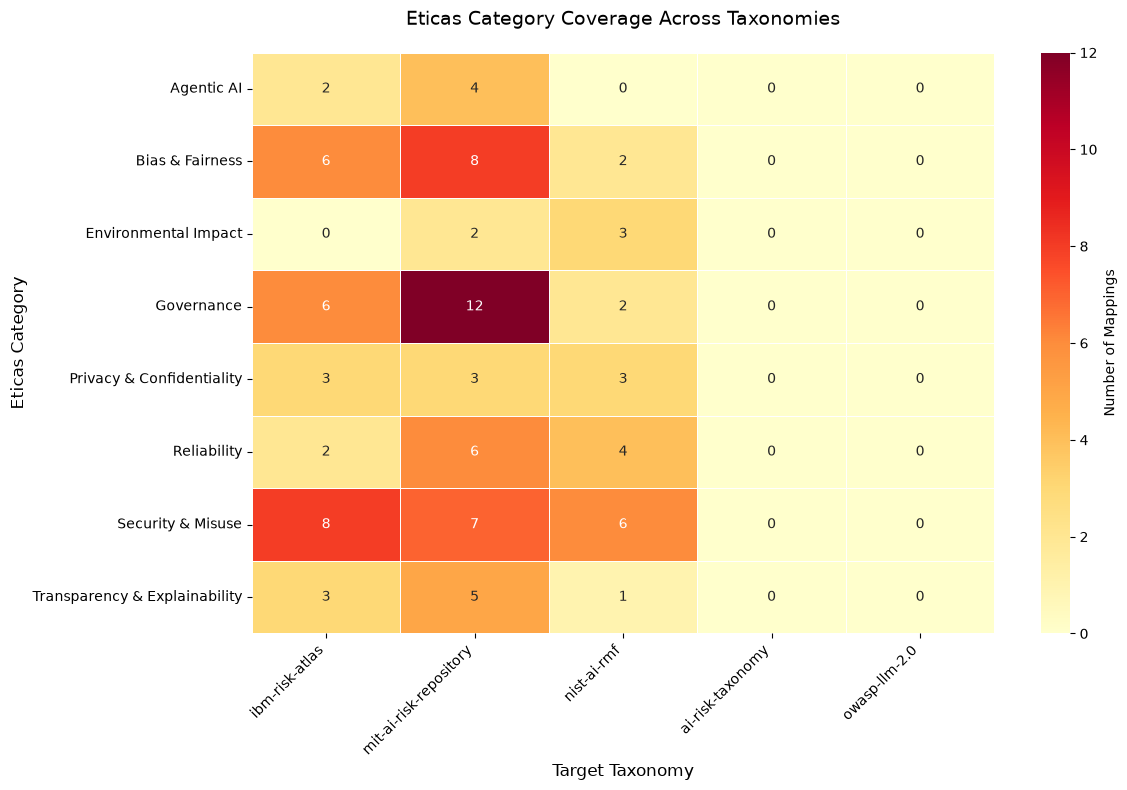

,ibm-risk-atlas,mit-ai-risk-repository,nist-ai-rmf,ai-risk-taxonomy,owasp-llm-2.0
category,,,,,
Agentic AI,2,4,0,0,0
Bias & Fairness,6,8,2,0,0
Environmental Impact,0,2,3,0,0
Governance,6,12,2,0,0
Privacy & Confidentiality,3,3,3,0,0
Reliability,2,6,4,0,0
Security & Misuse,8,7,6,0,0
Transparency & Explainability,3,5,1,0,0


In [14]:
# Create coverage matrix: Eticas top-level categories × target taxonomies
coverage_data = []

for category in sorted(top_level_groups, key=lambda x: x.name):
    # Get all child risks (including through sub-groups)
    child_risks = []
    
    # Direct child risks
    child_risks.extend([r for r in eticas_risks if r.isPartOf and category.id in r.isPartOf])
    
    # Risks through sub-groups
    sub_groups = [g for g in eticas_groups if hasattr(g, 'broader') and g.broader and category.id in g.broader]
    for sub_group in sub_groups:
        child_risks.extend([r for r in eticas_risks if r.isPartOf and sub_group.id in r.isPartOf])
    
    row = {'category': category.name}
    for tax in target_taxonomies:
        total_matches = 0
        for risk in child_risks:
            matches = get_match_summary(risk, [tax])
            total_matches += sum(len(v) for v in matches.values())
        row[tax] = total_matches
    
    coverage_data.append(row)

coverage_df = pd.DataFrame(coverage_data)
coverage_df = coverage_df.set_index('category')

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    coverage_df,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Number of Mappings'},
    linewidths=0.5
)
plt.title('Eticas Category Coverage Across Taxonomies', fontsize=14, pad=20)
plt.xlabel('Target Taxonomy', fontsize=12)
plt.ylabel('Eticas Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

coverage_df

## Key Insights and Divergences

In [15]:
# Analyze match type distribution
match_type_summary = defaultdict(int)
for risk in eticas_risks:
    matches = get_match_summary(risk, target_taxonomies)
    for match_type, match_list in matches.items():
        match_type_summary[match_type] += len(match_list)

print("\n=== Match Type Distribution ===")
total_mappings = sum(match_type_summary.values())
for match_type, count in sorted(match_type_summary.items(), key=lambda x: -x[1]):
    pct = (count / total_mappings * 100) if total_mappings > 0 else 0
    print(f"{match_type:15s}: {count:3d} ({pct:5.1f}%)")

print(f"\nTotal mappings: {total_mappings}")

# Agreement analysis
exact_and_close = match_type_summary['exactMatch'] + match_type_summary['closeMatch']
agreement_rate = (exact_and_close / total_mappings * 100) if total_mappings > 0 else 0
print(f"\nStrong agreement (exact + close matches): {exact_and_close} ({agreement_rate:.1f}%)")

# Novel categories analysis
print(f"\n=== Novel/Granular Eticas Categories ===")
print(f"Unmapped risks: {len(unmapped)} out of {len(eticas_risks)} ({len(unmapped)/len(eticas_risks)*100:.1f}%)")

# Highlight key novel categories
print("\nKey novel Eticas contributions:")
novel_keywords = ['agentic', 'environmental', 'organisational', 'readiness', 'climate', 'carbon', 'resource']
for risk_id, name, parent in unmapped:
    if any(keyword in name.lower() or keyword in (parent or '').lower() for keyword in novel_keywords):
        print(f"  - {name} (under {parent})")

# Categories with zero/low coverage
print("\n=== Categories with Low Mapping Coverage ===")
low_coverage = coverage_df[coverage_df.sum(axis=1) < 5]
if len(low_coverage) > 0:
    print("Categories with <5 total mappings:")
    for idx in low_coverage.index:
        total = low_coverage.loc[idx].sum()
        print(f"  - {idx}: {int(total)} mappings")
else:
    print("All categories have ≥5 mappings")

=== Match Type Distribution ===

closeMatch     :  45 ( 57.0%)

narrowMatch    :  17 ( 21.5%)

exactMatch     :  12 ( 15.2%)

relatedMatch   :   5 (  6.3%)

...

=== Novel/Granular Eticas Categories ===

Unmapped risks: 21 out of 64 (32.8%)

Key novel Eticas contributions:

=== Categories with Low Mapping Coverage ===

All categories have ≥5 mappings

## Export Crosswalk Tables

Export detailed crosswalk tables for further analysis or documentation.

In [16]:
# Export to CSV files
output_dir = 'eticas_crosswalk_outputs'
import os
os.makedirs(output_dir, exist_ok=True)

# Export match counts summary
match_counts.to_csv(f'{output_dir}/eticas_match_counts_summary.csv', index=False)
print(f"✓ Exported match counts summary")

# Export unmapped risks
unmapped_df.to_csv(f'{output_dir}/eticas_unmapped_risks.csv', index=False)
print(f"✓ Exported unmapped risks ({len(unmapped_df)} risks)")

# Export coverage heatmap data
coverage_df.to_csv(f'{output_dir}/eticas_coverage_heatmap.csv')
print(f"✓ Exported coverage heatmap data")

# Export hierarchy
hierarchy_data = []
for group in top_level_groups:
    hierarchy_data.append({
        'level': 1,
        'id': group.id,
        'name': group.name,
        'parent': None,
        'type': 'RiskGroup'
    })
for group in eticas_groups:
    if hasattr(group, 'broader') and group.broader:
        hierarchy_data.append({
            'level': 2,
            'id': group.id,
            'name': group.name,
            'parent': group.broader[0] if group.broader else None,
            'type': 'RiskGroup'
        })
for risk in eticas_risks:
    hierarchy_data.append({
        'level': 3,
        'id': risk.id,
        'name': risk.name,
        'parent': risk.isPartOf[0] if risk.isPartOf else None,
        'type': 'Risk'
    })
hierarchy_df = pd.DataFrame(hierarchy_data)
hierarchy_df.to_csv(f'{output_dir}/eticas_hierarchy.csv', index=False)
print(f"✓ Exported hierarchy structure")

# Export detailed crosswalks
ibm_crosswalk.to_csv(f'{output_dir}/eticas_to_ibm_crosswalk.csv', index=False)
mit_crosswalk.to_csv(f'{output_dir}/eticas_to_mit_crosswalk.csv', index=False)
nist_crosswalk.to_csv(f'{output_dir}/eticas_to_nist_crosswalk.csv', index=False)
air_crosswalk.to_csv(f'{output_dir}/eticas_to_air_crosswalk.csv', index=False)
owasp_crosswalk.to_csv(f'{output_dir}/eticas_to_owasp_crosswalk.csv', index=False)
print(f"✓ Exported detailed crosswalks for all 5 taxonomies")

print(f"\nAll outputs saved to: {output_dir}/")

✓ Exported match counts summary

✓ Exported unmapped risks (21 risks)

✓ Exported coverage heatmap data

✓ Exported hierarchy structure

✓ Exported detailed crosswalks for all 5 taxonomies

All outputs saved to: eticas_crosswalk_outputs/

## Summary

### Key Findings:

1. **Alignment**: The analysis shows strong alignment between Eticas and existing taxonomies, with the majority of mappings being exact or close matches.

2. **Hierarchical Organization**: Eticas uses a 2-3 level hierarchy:
   - 10 top-level categories (domains)
   - ~27 risk groups (sub-categories)
   - 64 individual risk concepts

3. **Eticas Granularity**: Notable areas where Eticas provides unique or more granular coverage:
   - **Agentic AI**: Dedicated category for autonomous AI systems and multi-agent risks
   - **Environmental Impact**: Climate, energy consumption, and resource waste
   - **Organisational Readiness**: Deployment context, capacity gaps, and governance maturity
   - **Measurement Validity**: Construct validity for evaluative AI systems
   - **Autonomy & Agency**: User autonomy, informed consent, and manipulation

4. **Coverage Distribution**: Different taxonomies cover different aspects:
   - **IBM Risk Atlas**: Strong on operational AI risks and bias
   - **MIT Repository**: Comprehensive causal risk modeling across all domains
   - **NIST AI RMF**: Governance, trustworthiness, and policy-oriented risks
   - **OWASP**: Technical security vulnerabilities and attack vectors
   - **AIR 2024**: General AI risk taxonomy with broad coverage

5. **Divergences**: Areas with different conceptual framing:
   - Eticas uses "Representational Harm" as a distinct subcategory vs others' broader "Bias" categories
   - Eticas distinguishes "Measurement Validity" from general reliability concerns
   - Environmental and organizational aspects are largely Eticas-specific
   - Eticas has more granular breakdown of bias types (outcome, representational, systemic)

### Recommendations:

- **For practitioners**: Use Eticas taxonomy for comprehensive audits covering emerging areas (agentic AI, environmental impact, organizational readiness)
- **For mappings**: The unmapped risks represent opportunities to extend other taxonomies
- **For harmonization**: Focus on strengthening mappings where exact/close matches already exist
- **For researchers**: Eticas hierarchy provides a useful organizational structure that could inform other taxonomies